In [2]:
pip install prophet

In [ ]:
#easy - missin data - large data

In [4]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
n = 365

In [7]:
dates = pd.date_range(start='2023-01-01', periods=n, freq='D')

In [14]:
seasonal_effect = 10 * np.sin(np.linspace(0, 2 * np.pi, n))

In [9]:
noise = np.random.normal(0,5, size=n)

In [10]:
trend = np.linspace(50,200,n)

In [11]:
holiday_effect = np.random.choice([0,1], size=n, p=[0.9,0.1])

In [15]:
sales = trend + seasonal_effect + noise + (holiday_effect * 30)

In [16]:
sales

array([ 48.79077619,  84.64574445,  56.90301385,  55.59003319,
        44.12886515,  52.26626644,  49.61490362,  53.26394901,
        49.10008203,  57.36552512,  55.38259478,  54.44668001,
        54.28242908,  59.29751913,  52.7166505 ,  63.0144588 ,
        63.14415697,  60.38018686,  64.63427377,  66.13107933,
        62.77730752,  66.33909354,  58.82390326,  61.882498  ,
        64.56494792,  65.80174759,  63.80013587,  58.60663551,
        67.16436196,  63.35308899, 112.42601374,  72.11591881,
        65.88881567, 108.66313748,  74.40574299,  79.26004153,
        72.9784998 ,  62.30131092,  87.05559962,  72.07547116,
        71.62479976,  70.42930311,  78.63140068,  75.23826806,
        74.38160445,  68.63994937,  74.80503637,  73.51262007,
        79.08450211,  85.3500189 ,  72.99979396,  79.79477441,
        80.0818944 ,  83.12797666,  82.58890156, 105.82566727,
        86.28023866,  86.38787435,  89.36586616,  79.92823637,
        80.9068624 ,  81.17718723,  83.63063867,  72.72

In [17]:
df = pd.DataFrame({
    'date': dates,
    'sales': sales,
    'holiday_effect': holiday_effect
})

In [18]:
df.head()

,date,sales,holiday_effect
0,2023-01-01,48.790776,0
1,2023-01-02,84.645744,1
2,2023-01-03,56.903014,0
3,2023-01-04,55.590033,0
4,2023-01-05,44.128865,0


In [21]:
df_prophet = df[["date", "sales"]].rename(columns = {"date": "ds", "sales": "y"})

In [22]:
df_prophet.tail()

,ds,y
360,2023-12-27,195.879150
361,2023-12-28,190.130708
362,2023-12-29,199.916817
363,2023-12-30,200.841053
364,2023-12-31,190.110176


In [23]:
model = Prophet()

In [24]:
model.fit(df_prophet)

09:30:40 - cmdstanpy - INFO - Chain [1] start processing
09:30:40 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
future_dates = pd.date_range(start="2024-01-01", periods=30,freq="D")

In [26]:
future_df = pd.DataFrame({"ds": future_dates})

In [27]:
future_df.head(10)

,ds
0,2024-01-01
1,2024-01-02
2,2024-01-03
3,2024-01-04
4,2024-01-05
5,2024-01-06
6,2024-01-07
7,2024-01-08
8,2024-01-09
9,2024-01-10


In [28]:
forecast = model.predict(future_df)

In [29]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-01-01,198.800662,184.550812,212.623628,198.800662,198.800662,0.278770,0.278770,0.278770,0.278770,0.278770,0.278770,0.0,0.0,0.0,199.079432
1,2024-01-02,199.249567,184.934083,213.164756,199.249567,199.249567,0.412227,0.412227,0.412227,0.412227,0.412227,0.412227,0.0,0.0,0.0,199.661794
2,2024-01-03,199.698473,183.429336,211.896531,199.698473,199.700933,-2.182125,-2.182125,-2.182125,-2.182125,-2.182125,-2.182125,0.0,0.0,0.0,197.516348
3,2024-01-04,200.147378,184.764022,211.581503,200.145947,200.154164,-2.196006,-2.196006,-2.196006,-2.196006,-2.196006,-2.196006,0.0,0.0,0.0,197.951372
4,2024-01-05,200.596284,187.058321,214.583807,200.588462,200.609449,0.574301,0.574301,0.574301,0.574301,0.574301,0.574301,0.0,0.0,0.0,201.170585
5,2024-01-06,201.045189,187.661007,215.163221,201.026386,201.068843,0.379272,0.379272,0.379272,0.379272,0.379272,0.379272,0.0,0.0,0.0,201.424461
6,2024-01-07,201.494094,189.542637,218.461429,201.465794,201.531687,2.733562,2.733562,2.733562,2.733562,2.733562,2.733562,0.0,0.0,0.0,204.227656
7,2024-01-08,201.943000,188.511465,216.096950,201.902078,201.995832,0.278770,0.278770,0.278770,0.278770,0.278770,0.278770,0.0,0.0,0.0,202.221770
8,2024-01-09,202.391905,189.768845,217.558994,202.336620,202.462867,0.412227,0.412227,0.412227,0.412227,0.412227,0.412227,0.0,0.0,0.0,202.804132
9,2024-01-10,202.840810,186.756152,213.918299,202.774614,202.925714,-2.182125,-2.182125,-2.182125,-2.182125,-2.182125,-2.182125,0.0,0.0,0.0,200.658685


In [32]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].head()

,ds,yhat,yhat_lower,yhat_upper
0,2024-01-01,199.079432,184.550812,212.623628
1,2024-01-02,199.661794,184.934083,213.164756
2,2024-01-03,197.516348,183.429336,211.896531
3,2024-01-04,197.951372,184.764022,211.581503
4,2024-01-05,201.170585,187.058321,214.583807


Text(82.72222222222221, 0.5, 'Sales')

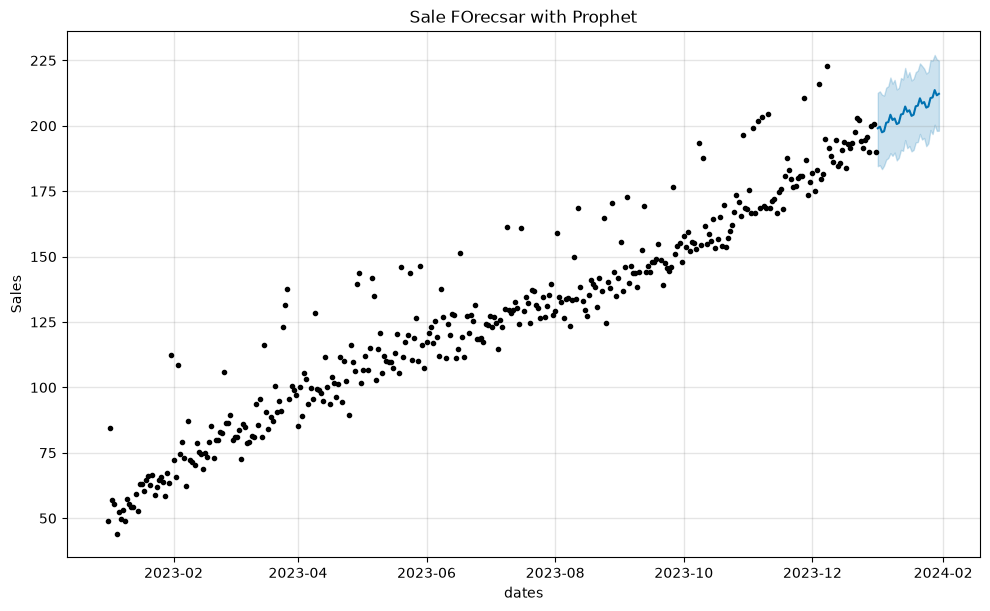

In [33]:
model.plot(forecast)
plt.title("Sale FOrecsar with Prophet")
plt.xlabel("dates")
plt.ylabel("Sales")

In [34]:
import pickle

with open("prophet_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [35]:
with open("prophet_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

In [36]:
loaded_model

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
09:37:28 - cmdstanpy - INFO - Chain [1] start processing
09:37:28 - cmdstanpy - INFO - Chain [1] done processing


--- BẢNG SO SÁNH KẾT QUẢ DỰ BÁO TRÊN TẬP TEST ---


,ds,Actual,Forecast,Absolute_Error,Error_Percentage
0,2023-12-02,182.375834,195.924909,13.549075,7.429205
1,2023-12-03,215.680304,195.907403,19.772901,9.167690
2,2023-12-04,189.035030,198.267570,9.232540,4.884037
3,2023-12-05,178.668339,201.716202,23.047864,12.899803
4,2023-12-06,187.272988,197.201612,9.928623,5.301685
5,2023-12-07,200.663869,200.559625,0.104245,0.051950
6,2023-12-08,189.388871,199.746399,10.357528,5.468921
7,2023-12-09,189.692525,201.039700,11.347176,5.981878
8,2023-12-10,195.528346,200.415928,4.887582,2.499680
9,2023-12-11,181.130683,202.104235,20.973552,11.579237


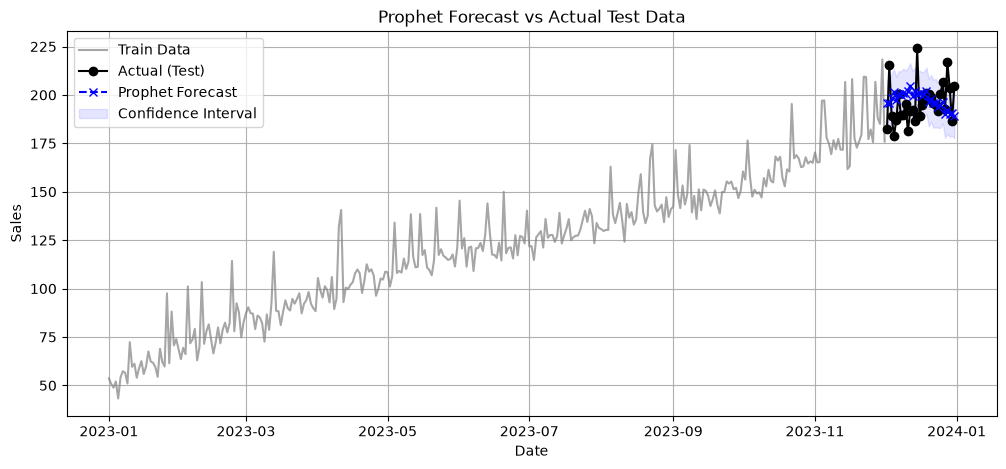

In [39]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")

# 1. Tạo dữ liệu giả lập (365 ngày)
n = 365
dates = pd.date_range(start='2023-01-01', periods=n, freq='D')
seasonal_effect = 10 * np.sin(np.linspace(0, 2 * np.pi, n))
noise = np.random.normal(0, 5, size=n)
trend = np.linspace(50, 200, n)
holiday_effect = np.random.choice([0, 1], size=n, p=[0.9, 0.1])
sales = trend + seasonal_effect + noise + (holiday_effect * 30)

df = pd.DataFrame({
    'ds': dates,
    'y': sales
})

# 2. Chia tập Train và Test (30 ngày cuối làm tập Test)
horizon = 30
train_df = df[:-horizon]
test_df = df[-horizon:].copy()

# 3. Khởi tạo và Huấn luyện mô hình Prophet trên tập Train
model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(train_df)

# 4. Dự báo cho đúng số ngày của tập Test
future_df = model.make_future_dataframe(periods=horizon)
forecast = model.predict(future_df)

# Lấy phần dự báo 30 ngày cuối
forecast_test = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(horizon).copy()

# 5. Tạo bảng so sánh chi tiết (Tránh lỗi KeyError bằng cách map trực tiếp giá trị)
comparison_df = pd.DataFrame({
    'ds': test_df['ds'].values,
    'Actual': test_df['y'].values,
    'Forecast': forecast_test['yhat'].values,
    'Lower': forecast_test['yhat_lower'].values,
    'Upper': forecast_test['yhat_upper'].values
})

# Tính sai số tuyệt đối và tỉ lệ phần trăm sai số (%)
comparison_df['Absolute_Error'] = np.abs(comparison_df['Actual'] - comparison_df['Forecast'])
comparison_df['Error_Percentage'] = (comparison_df['Absolute_Error'] / comparison_df['Actual']) * 100

# Format lại ngày tháng dạng chuỗi cho dễ nhìn trên bảng
comparison_df['ds'] = pd.to_datetime(comparison_df['ds']).dt.strftime('%Y-%m-%d')

print("--- BẢNG SO SÁNH KẾT QUẢ DỰ BÁO TRÊN TẬP TEST ---")
# Trong Jupyter Notebook / Colab dùng display(), nếu lỗi dùng print(comparison_df)
display(comparison_df[['ds', 'Actual', 'Forecast', 'Absolute_Error', 'Error_Percentage']])

# 6. Vẽ đồ thị so sánh trực quan
plt.figure(figsize=(12, 5))
plt.plot(train_df['ds'], train_df['y'], label="Train Data", color="gray", alpha=0.7)
plt.plot(test_df['ds'], test_df['y'], label="Actual (Test)", color="black", marker='o')
plt.plot(forecast_test['ds'], forecast_test['yhat'], label="Prophet Forecast", color="blue", linestyle='--', marker='x')
plt.fill_between(
    forecast_test['ds'], 
    forecast_test['yhat_lower'], 
    forecast_test['yhat_upper'], 
    color='blue', alpha=0.1, label='Confidence Interval'
)
plt.title("Prophet Forecast vs Actual Test Data")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

# 7. Lưu mô hình bằng pickle
with open("prophet_model.pkl", "wb") as f:
    pickle.dump(model, f)

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
09:38:17 - cmdstanpy - INFO - Chain [1] start processing
09:38:17 - cmdstanpy - INFO - Chain [1] done processing


--- BẢNG SO SÁNH KẾT QUẢ DỰ BÁO TRÊN TẬP TEST ---


,ds,Actual,Forecast,Absolute_Error,Error_Percentage
0,2023-12-02,191.810549,190.861130,0.949418,0.494977
1,2023-12-03,186.506521,194.143752,7.637231,4.094887
2,2023-12-04,183.417989,195.661320,12.243331,6.675098
3,2023-12-05,182.626572,196.932598,14.306026,7.833485
4,2023-12-06,185.896140,201.366007,15.469867,8.321779
5,2023-12-07,176.289187,200.603311,24.314124,13.792181
6,2023-12-08,180.754151,203.872101,23.117950,12.789720
7,2023-12-09,187.325499,205.111234,17.785735,9.494562
8,2023-12-10,185.992138,208.264926,22.272788,11.975123
9,2023-12-11,189.086390,209.510001,20.423611,10.801206


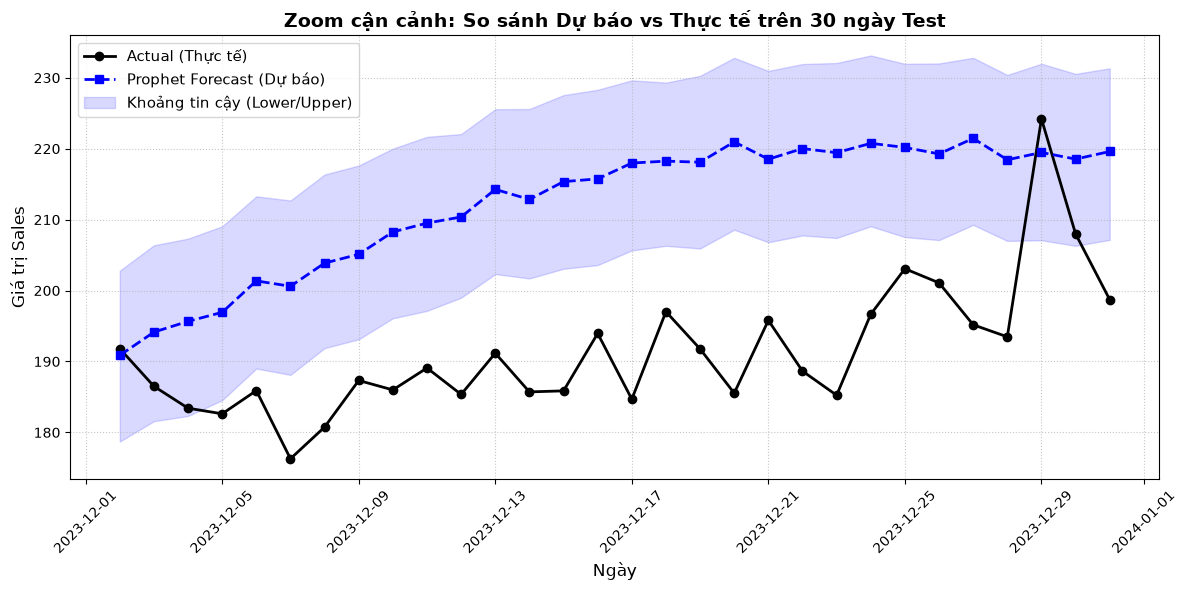

Đã lưu mô hình thành công vào file 'prophet_model.pkl'!


In [40]:
# Cài đặt thư viện nếu chưa có (chạy trên Jupyter/Colab)
# !pip install prophet

from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")

# 1. Tạo dữ liệu giả lập (365 ngày)
n = 365
dates = pd.date_range(start='2023-01-01', periods=n, freq='D')
seasonal_effect = 10 * np.sin(np.linspace(0, 2 * np.pi, n))
noise = np.random.normal(0, 5, size=n)
trend = np.linspace(50, 200, n)
holiday_effect = np.random.choice([0, 1], size=n, p=[0.9, 0.1])
sales = trend + seasonal_effect + noise + (holiday_effect * 30)

df = pd.DataFrame({
    'ds': dates,
    'y': sales
})

# 2. Chia tập Train và Test (30 ngày cuối làm tập Test)
horizon = 30
train_df = df[:-horizon]
test_df = df[-horizon:].copy()

# 3. Khởi tạo và Huấn luyện mô hình Prophet trên tập Train
model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(train_df)

# 4. Dự báo cho đúng số ngày của tập Test
future_df = model.make_future_dataframe(periods=horizon)
forecast = model.predict(future_df)

# Lấy phần dự báo 30 ngày cuối
forecast_test = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(horizon).copy()

# 5. Tạo bảng so sánh chi tiết giữa Thực tế và Dự báo
comparison_df = pd.DataFrame({
    'ds': test_df['ds'].values,
    'Actual': test_df['y'].values,
    'Forecast': forecast_test['yhat'].values,
    'Lower': forecast_test['yhat_lower'].values,
    'Upper': forecast_test['yhat_upper'].values
})

# Tính sai số tuyệt đối và tỉ lệ phần trăm sai số (%)
comparison_df['Absolute_Error'] = np.abs(comparison_df['Actual'] - comparison_df['Forecast'])
comparison_df['Error_Percentage'] = (comparison_df['Absolute_Error'] / comparison_df['Actual']) * 100

# Format lại ngày tháng dạng chuỗi cho dễ nhìn trên bảng
comparison_df['ds'] = pd.to_datetime(comparison_df['ds']).dt.strftime('%Y-%m-%d')

print("--- BẢNG SO SÁNH KẾT QUẢ DỰ BÁO TRÊN TẬP TEST ---")
display(comparison_df[['ds', 'Actual', 'Forecast', 'Absolute_Error', 'Error_Percentage']])

# 6. Vẽ đồ thị ZOOM CẬN CẢNH vào 30 ngày tập Test để nhìn cho rõ
plt.figure(figsize=(12, 6))

plt.plot(test_df['ds'], test_df['y'], label="Actual (Thực tế)", color="black", marker='o', linewidth=2, markersize=6)
plt.plot(forecast_test['ds'], forecast_test['yhat'], label="Prophet Forecast (Dự báo)", color="blue", linestyle='--', marker='s', linewidth=2, markersize=6)

# Vùng khoảng tin cậy
plt.fill_between(
    forecast_test['ds'], 
    forecast_test['yhat_lower'], 
    forecast_test['yhat_upper'], 
    color='blue', alpha=0.15, label='Khoảng tin cậy (Lower/Upper)'
)

plt.title("Zoom cận cảnh: So sánh Dự báo vs Thực tế trên 30 ngày Test", fontsize=14, fontweight='bold')
plt.xlabel("Ngày", fontsize=12)
plt.ylabel("Giá trị Sales", fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# 7. Lưu mô hình bằng pickle
with open("prophet_model.pkl", "wb") as f:
    pickle.dump(model, f)
print("Đã lưu mô hình thành công vào file 'prophet_model.pkl'!")